In [3]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as pf
#import my_plot_style as mps
import numpy as np
import scipy.stats as ss
import statistics 
#mps.my_plot_style()

# SDSS quasar spectra practice
### https://www.dropbox.com/s/emzrmm1hd86ihim/SDSS_QSO_spectra_short.fits?dl=0

In [8]:
data = pf.open('SDSS_QSO_spectra.fits')
spectra = data[0].data #spectra[i,j] i object and j pixel
inv = data[1].data # Inverse-variance of the data
wavelength = data[2].data # wavelength 

3010


Text(0, 0.5, 'Normalized flux')

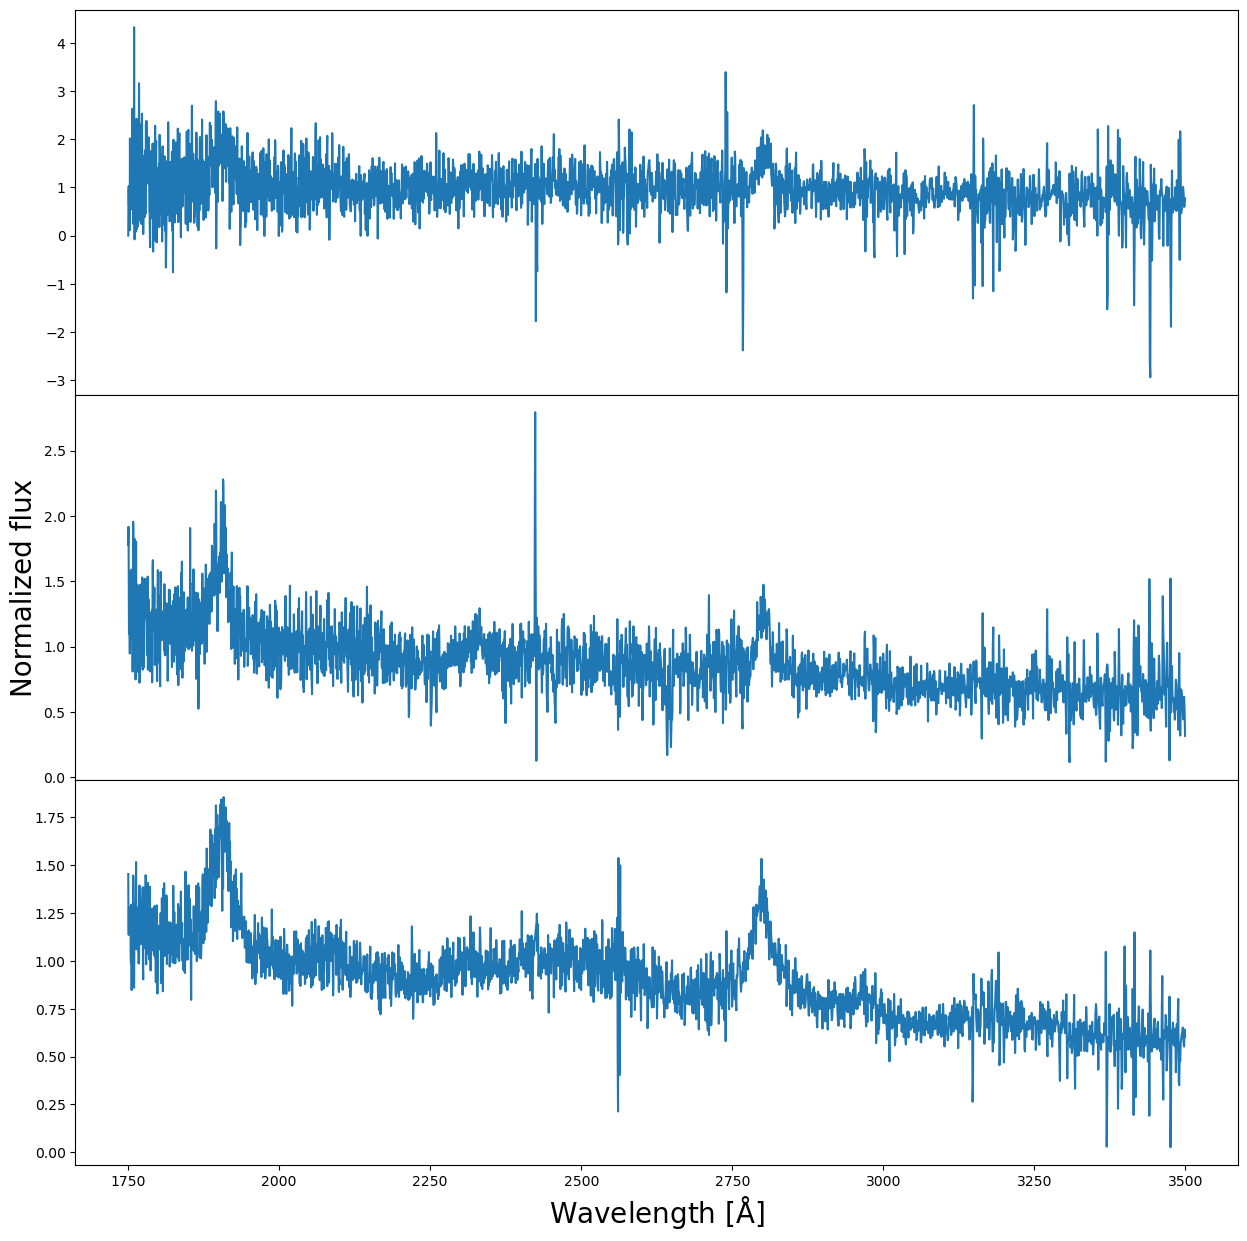

In [4]:
#len(spectra)
plt.figure(figsize=(15,15))
plt.subplots_adjust(hspace=0)
for i in range(0,3):
    plt.subplot(3,1,i+1)
    plt.plot(wavelength,spectra[i,:])
plt.xlabel('Wavelength [$\\rm \\AA$]',fontsize=20)
plt.subplot(3,1,2)
plt.ylabel('Normalized flux',fontsize=20)

# Exercise 1: Write a code to produce a composite spectrum (a combined spectrum), using each estimator:

mean 

median

sigma clipping 

inverse-variance weighted mean and 

geometric mean

### Feel free to use the developed library e.g. scipy


In [105]:
### Code
#1. Compute the mean and standard deviation of the spectra

means = []
medians = []
stds = []
sigma_clippeds = []
inv_var_weighted_means = []
geom_means = []


for j in range(len(spectra[0])):
    append_tem = []
    geo_append_tem = []
    for i in range(len(spectra)):
        append_tem.append(spectra[i][j])
        if spectra[i][j] >= 0:
            geo_append_tem.append(spectra[i][j])
        
    
    mean = statistics.mean(append_tem)
    median = statistics.median(append_tem)
    std = statistics.stdev(append_tem)
    sigma_clipped = np.mean(ss.sigmaclip(append_tem, low=3, high=3)[0])
    inv_var_weighted_mean = np.average(append_tem, weights=inv[:, j])
    geom_mean = ss.gmean(geo_append_tem)
    

    
    means.append(mean)
    medians.append(median)
    stds.append(std)
    sigma_clippeds.append(sigma_clipped)
    inv_var_weighted_means.append(inv_var_weighted_mean)
    geom_means.append(geom_mean)


    

In [107]:

print(geom_means)

[1.2607496218065741, 1.277686106612207, 1.2872339113117306, 1.2640528108783058, 1.261905672930767, 1.2687163433224153, 1.2395120581866024, 1.2359278107257055, 1.2570708130482946, 1.2571933214306825, 1.2412843593571508, 1.2632411506080041, 1.2136431409912236, 1.2411901318409044, 1.2271856066017006, 1.2100181645843524, 1.2005918560235016, 1.2161812983944298, 1.2340530746994567, 1.2168530550938528, 1.222474193950784, 1.2297936183952773, 1.244188892866038, 1.17153970924449, 1.2129209775556664, 1.2170460111797032, 1.1711694384587623, 1.1812786180914217, 1.1964612197188365, 1.18148536407476, 1.1829489688505956, 1.1497399668260413, 1.1891816284150667, 1.173351177054026, 1.1502242920808616, 1.1658731623417369, 1.148943679798472, 1.1858417216189003, 1.168992167582058, 1.1449052946499976, 1.1592696830175897, 1.1667798227591233, 1.1696857639006784, 1.181360729841057, 1.188431153355748, 1.14927844722248, 1.1635696463324618, 1.1758624581875075, 1.130837807989113, 1.158762594727034, 1.18889244008657

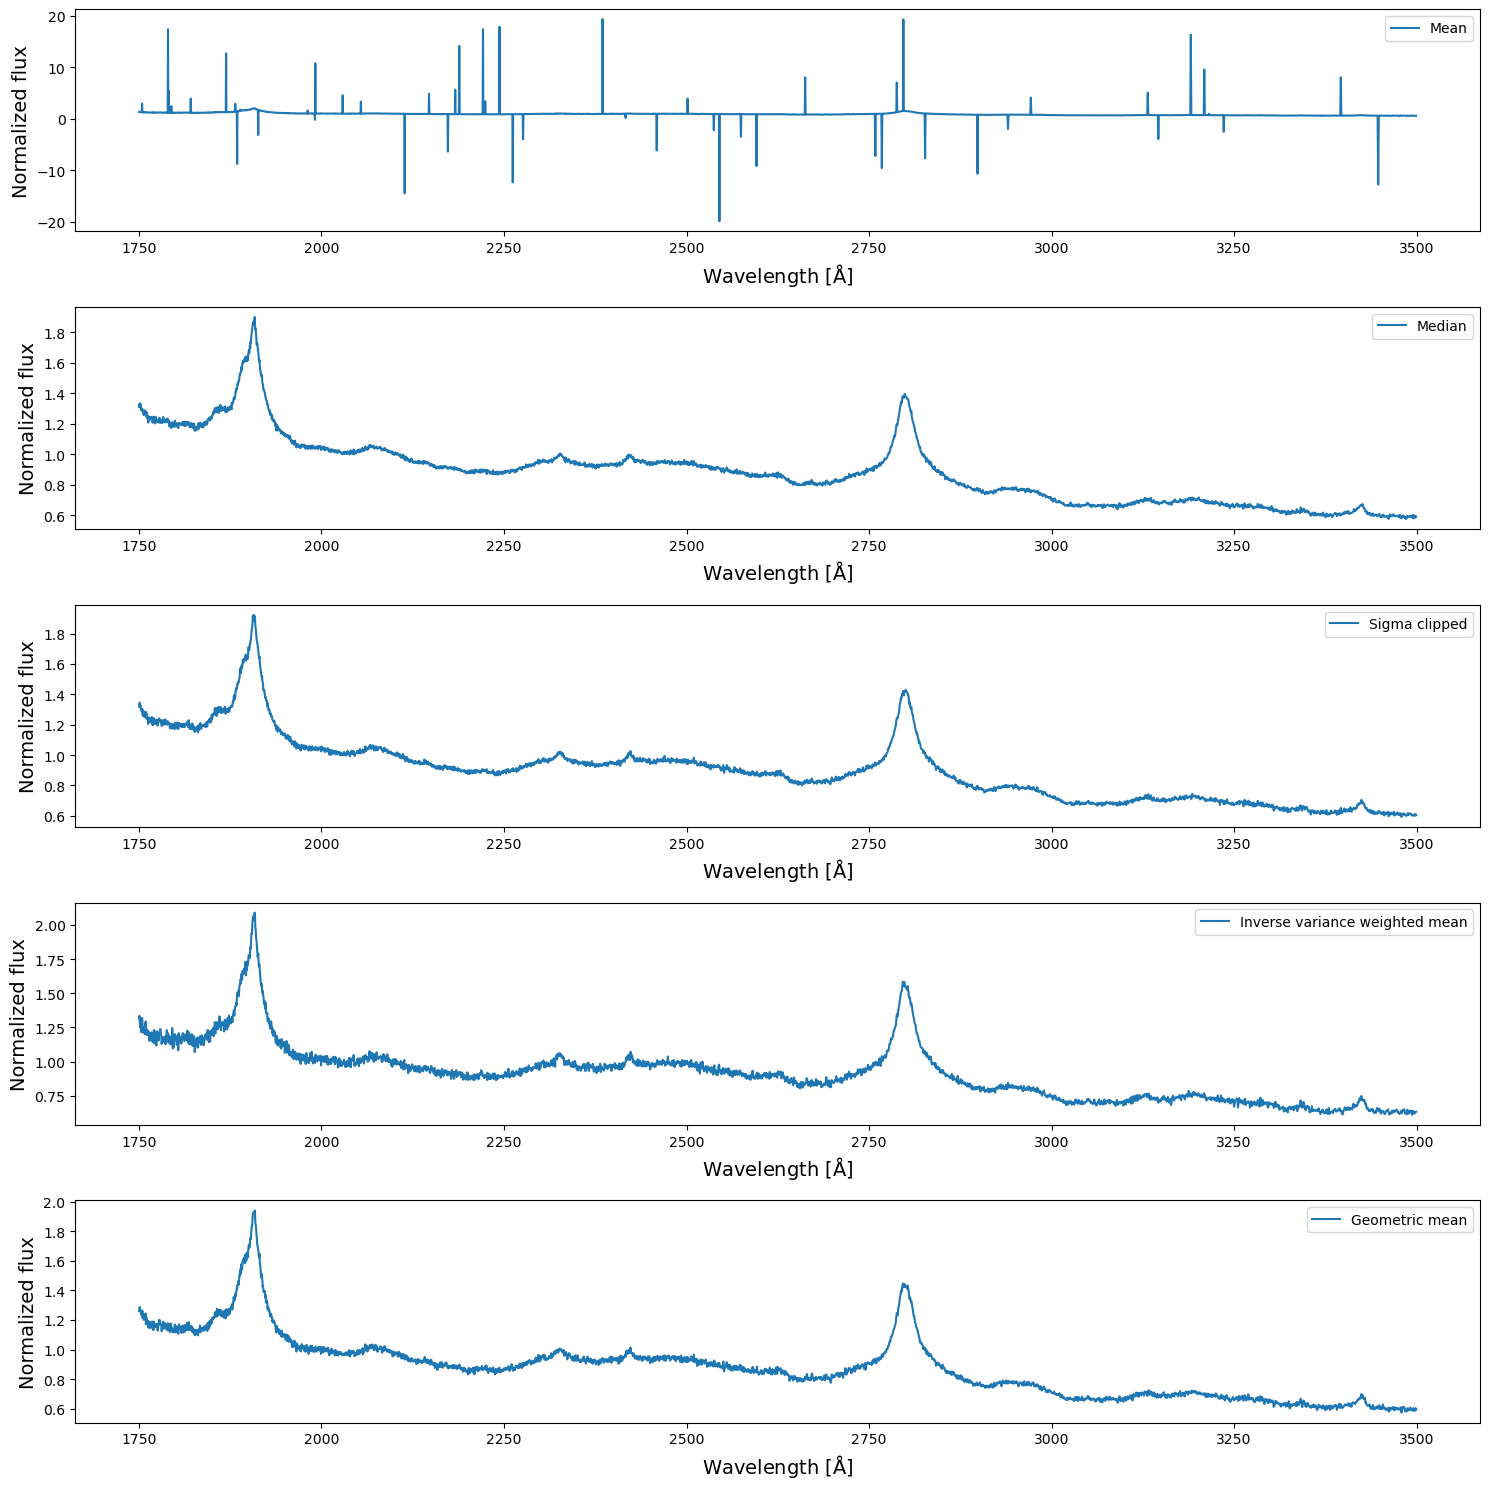

In [106]:
fig, ax = plt.subplots(5,1, figsize=(15,15)) 

# Plot the results
ax[0].plot(wavelength, means, label='Mean')
ax[1].plot(wavelength, medians, label='Median')
ax[2].plot(wavelength, sigma_clippeds, label='Sigma clipped')
ax[3].plot(wavelength, inv_var_weighted_means, label='Inverse variance weighted mean')
ax[4].plot(wavelength, geom_means, label='Geometric mean')

# Add labels
for i in range(5):
    ax[i].set_xlabel('Wavelength [$\\rm \\AA$]',fontsize=14)
    ax[i].set_ylabel('Normalized flux', fontsize=14)
    ax[i].legend()
    
plt.tight_layout()


# Exercise 2: 
### a. Use random generator to perform a simple simulation and demonstrate that 
### the error of the mean 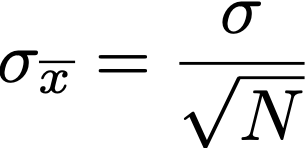

### b. Write a code to show (1) the bootstrap error is consistent with the theoretical value and (2) the bootstrap error as a function of bootstrap time.

# Gaussian / normal distribution
## $Prob(x) =\frac{1}{\sigma \sqrt(2\pi)} exp[-\frac{(x-\mu)^{2}}{2\sigma^{2}}]$

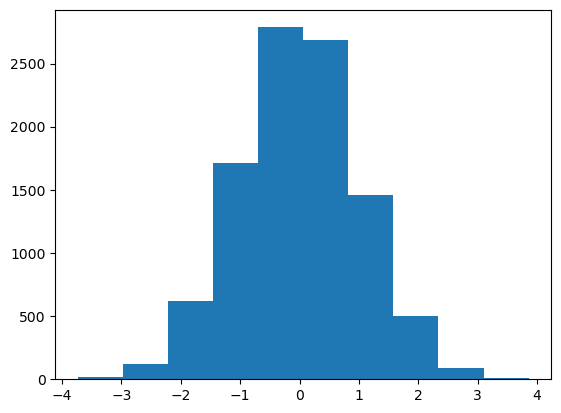

In [48]:
# a.
mu = 0
sigma = 1
n_point = 10000
random_data = np.random.normal(mu,sigma,n_point)
_ = plt.hist(random_data)


Mean = 0.013
the standard deviation=1.026
the error of the mean=0.032


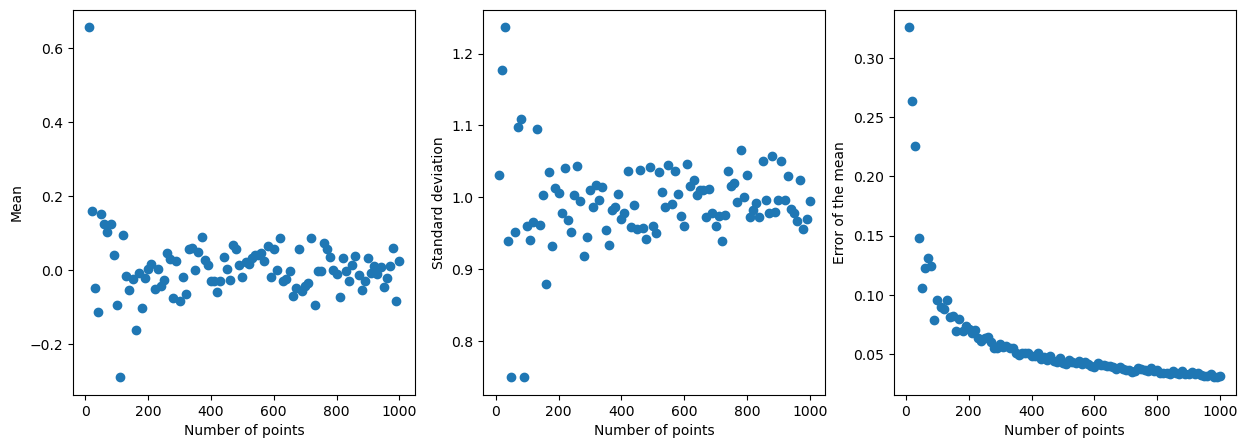

In [79]:
print('Mean = %0.3f' % (np.mean(random_data)))
print('the standard deviation=%0.3f' % (np.std(random_data)))
print('the error of the mean=%0.3f' % (np.std(random_data)/np.sqrt(len(random_data))))

# b.
number_of_points = np.linspace(10,1000,100)
mean = []
std = []
error = []
for n in number_of_points:
    random_data = np.random.normal(mu,sigma,int(n))
    mean.append(np.mean(random_data))
    std.append(np.std(random_data))
    error.append(np.std(random_data)/np.sqrt(len(random_data)))

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.scatter(number_of_points,mean)
plt.xlabel('Number of points')
plt.ylabel('Mean')
plt.subplot(1,3,2)
plt.scatter(number_of_points,std)
plt.xlabel('Number of points')
plt.ylabel('Standard deviation')
plt.subplot(1,3,3)
plt.scatter(number_of_points,error)
plt.xlabel('Number of points')
plt.ylabel('Error of the mean')

plt.show()

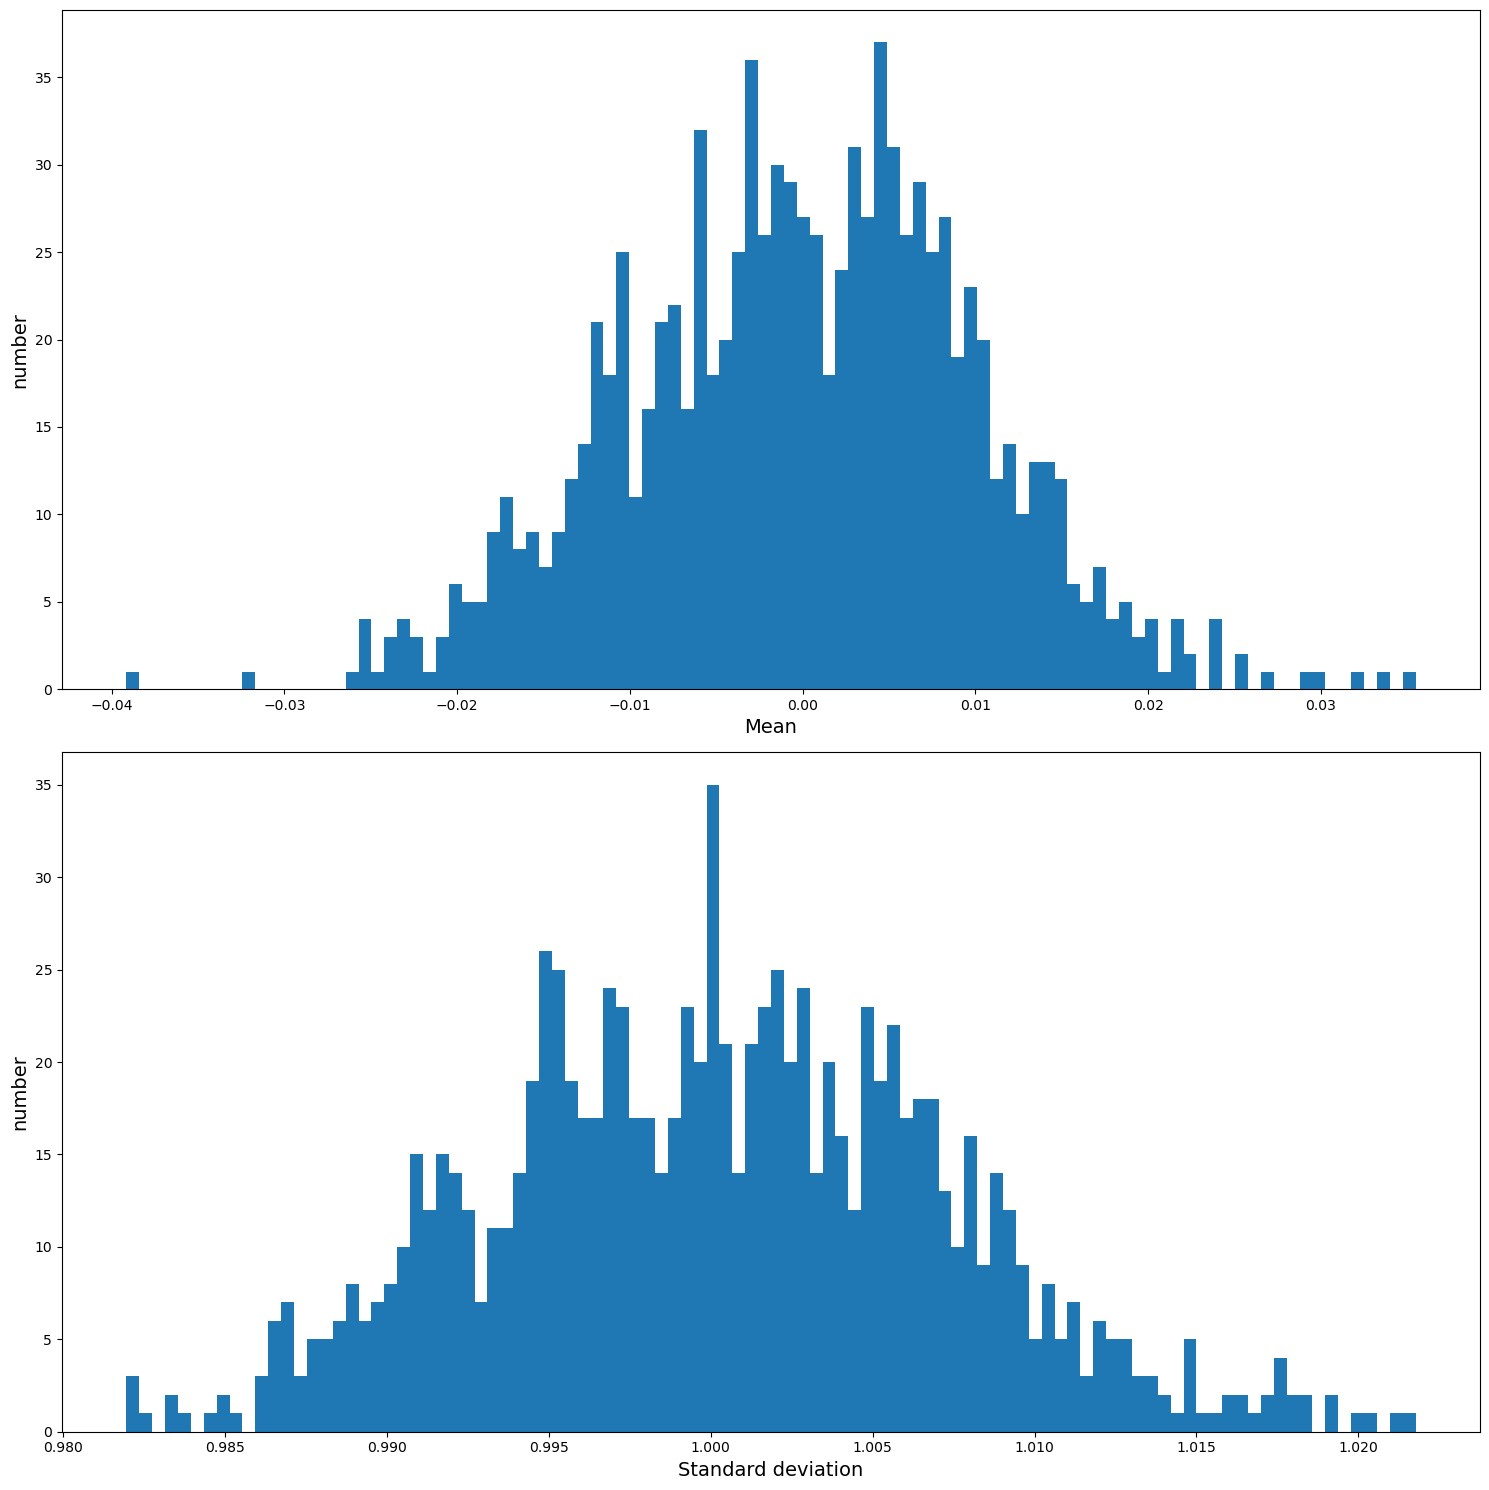

Mean of the means = -0.000
the standard deviations = 1.000
Mean of the error of the mean = 0.010


In [50]:
### You can run many simuations and look at the distribution of the mean and the standard deviation of the distribution
n_simulations = 1000
means = []
stds = []
for i in range(n_simulations):
    random_data = np.random.normal(mu,sigma,n_point)
    means.append(np.mean(random_data))
    stds.append(np.std(random_data))

fig, ax = plt.subplots(2,1, figsize=(15,15))
ax[0].hist(means, bins=100)
ax[0].set_xlabel('Mean',fontsize=14)
ax[0].set_ylabel('number',fontsize=14)
ax[1].hist(stds, bins=100)
ax[1].set_xlabel('Standard deviation',fontsize=14)
ax[1].set_ylabel('number',fontsize=14)
plt.tight_layout()
plt.show()
print('Mean of the means = %0.3f' % (np.mean(means)))
print('the standard deviations = %0.3f' % (np.mean(stds)))
print('Mean of the error of the mean = %0.3f' % (np.mean(stds)/np.sqrt(n_point)))


Mean of the means = -0.016
the standard deviations = 1.006
Mean of the error of the mean = 0.010


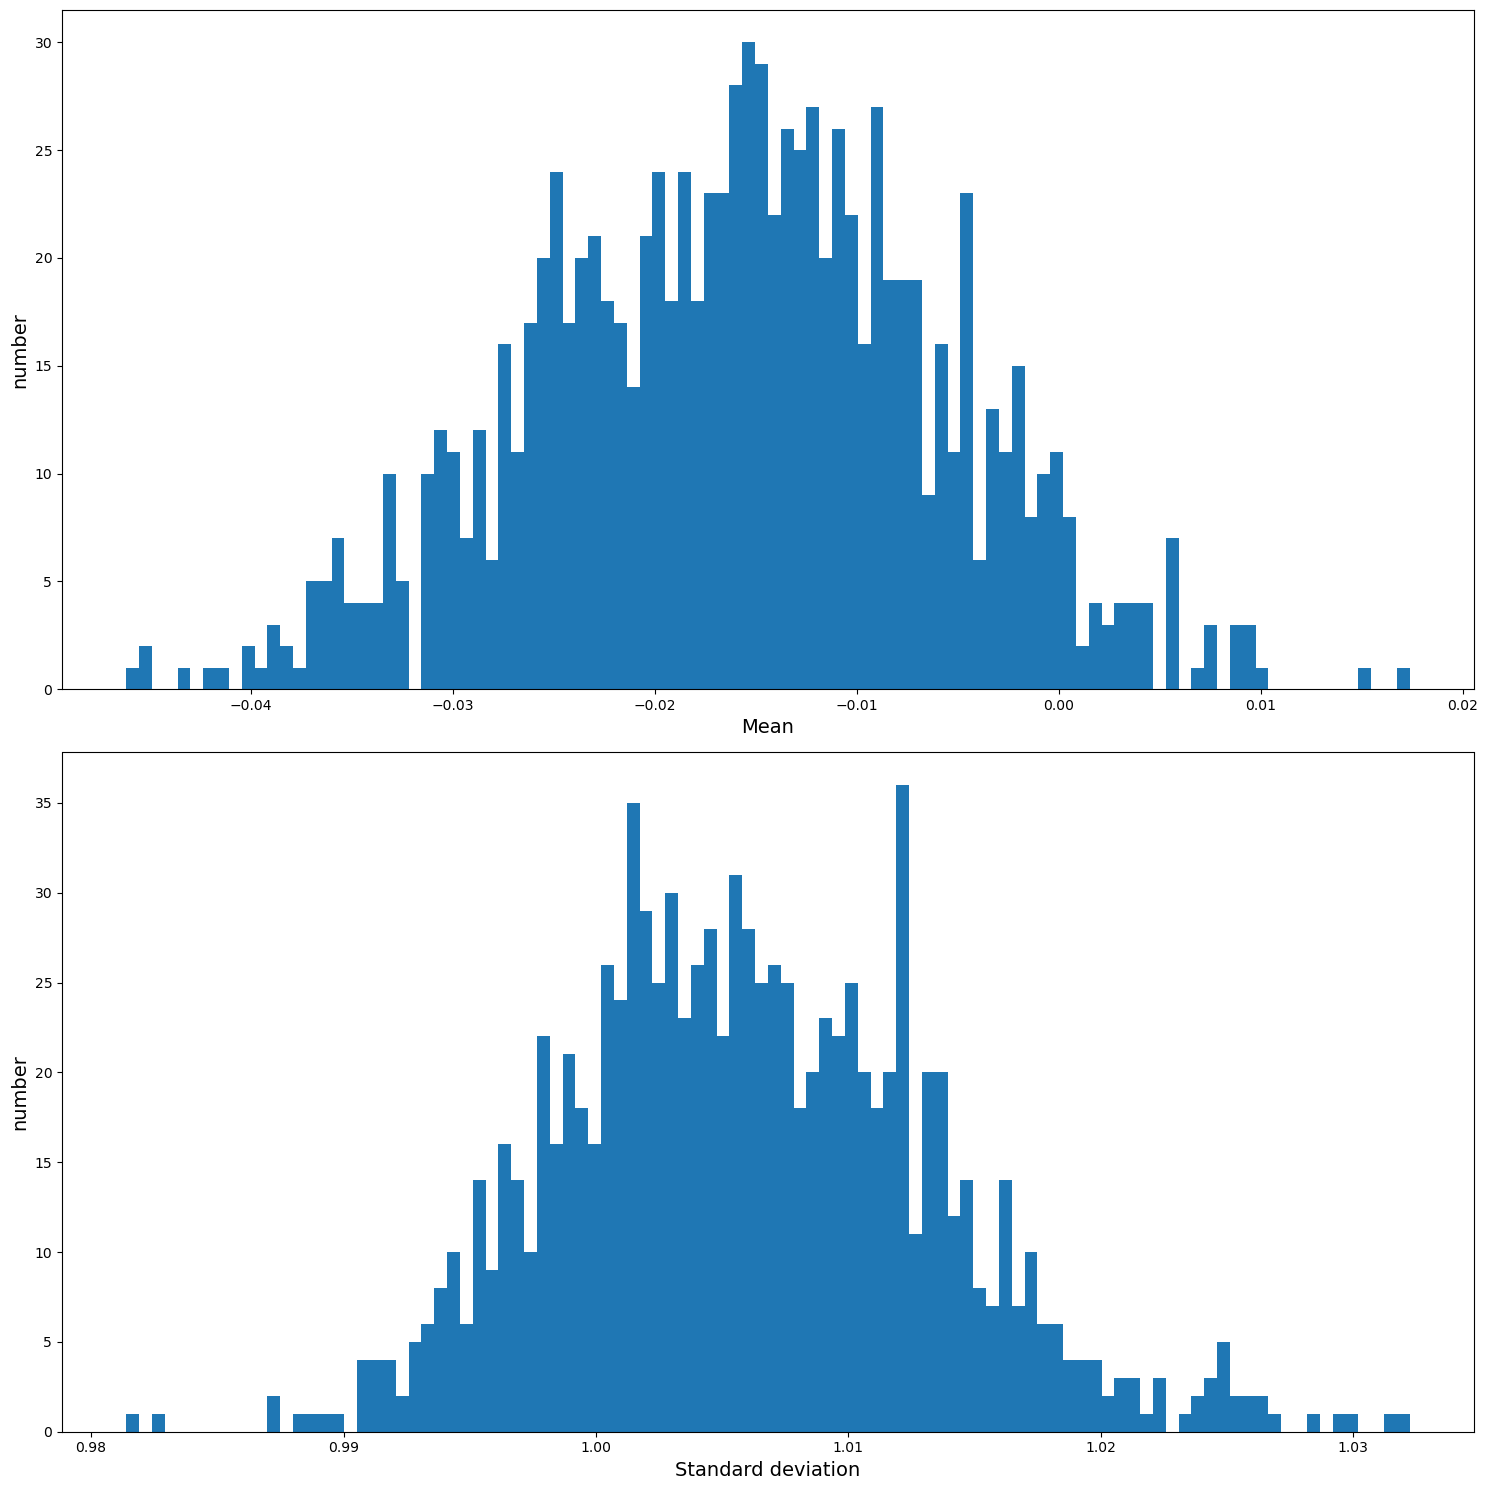

In [54]:
### b. Bootstrap code - using a single normal distribution dataset, 
### but randomly create new dataset from the original dataset and estimate the error of mean

n_bootstrap = 1000
means = []
stds = []
for i in range(n_bootstrap):
    random_data_bs = np.random.choice(random_data, n_point)
    means.append(np.mean(random_data_bs))
    stds.append(np.std(random_data_bs))


meanerr = (np.mean(stds)/np.sqrt(n_point))
print('Mean of the means = %0.3f' % (np.mean(means)))
print('the standard deviations = %0.3f' % (np.mean(stds)))
print('Mean of the error of the mean = %0.3f' % (np.mean(stds)/np.sqrt(n_point)))

fig, ax = plt.subplots(2,1, figsize=(15,15))
ax[0].hist(means, bins=100)
ax[0].set_xlabel('Mean',fontsize=14)
ax[0].set_ylabel('number',fontsize=14)
ax[1].hist(stds, bins=100)
ax[1].set_xlabel('Standard deviation',fontsize=14)
ax[1].set_ylabel('number',fontsize=14)
plt.tight_layout()
plt.show()


Mean = 500.013
the standard deviation=289.675
the error of the mean=2.897
Mean of the means = 498.731
the standard deviations = 292.519
Mean of the error of the mean = 2.925
Mean of the means = 499.396
the standard deviations = 289.375
Mean of the error of the mean = 2.894
Mean of the means = 500.295
the standard deviations = 289.731
Mean of the error of the mean = 2.897
Mean of the means = 500.090
the standard deviations = 289.335
Mean of the error of the mean = 2.893
Mean of the means = 499.502
the standard deviations = 289.472
Mean of the error of the mean = 2.895
Mean of the means = 499.971
the standard deviations = 289.558
Mean of the error of the mean = 2.896
Mean of the means = 500.565
the standard deviations = 289.711
Mean of the error of the mean = 2.897
Mean of the means = 499.706
the standard deviations = 289.486
Mean of the error of the mean = 2.895
Mean of the means = 500.498
the standard deviations = 289.768
Mean of the error of the mean = 2.898
Mean of the means = 499.80

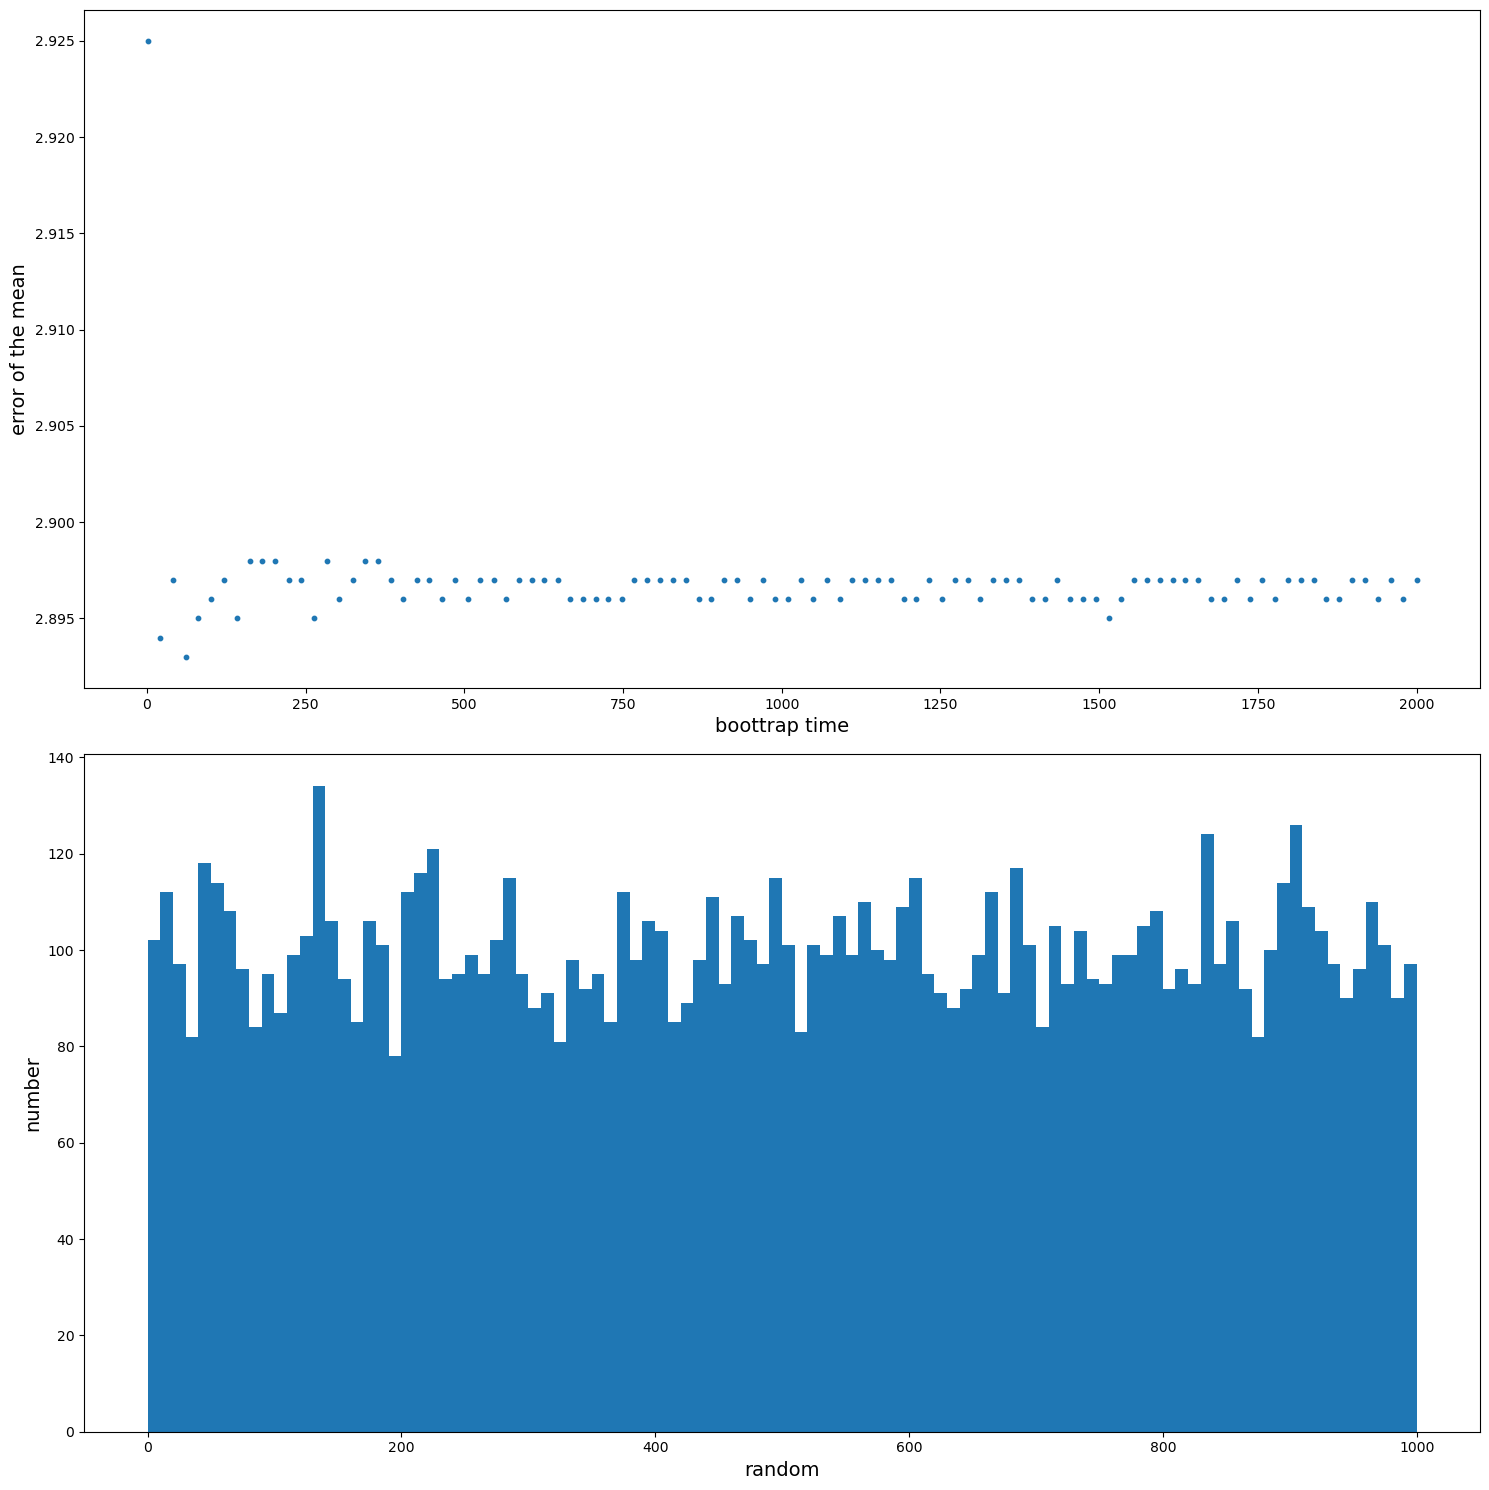

In [82]:
### claculate how many time bootstrap is needed to get the same result as the simulation
means = []
stds = []
errors = []
n_bootstrap = np.linspace(1, 2000, 100, dtype=int)

random_data = np.random.uniform(0, 1000, n_point)
mean = np.mean(random_data)
std = np.std(random_data)
error = std/np.sqrt(len(random_data))
print('Mean = %0.3f' % (mean))
print('the standard deviation=%0.3f' % (std))
print('the error of the mean=%0.3f' % (error))


for n in n_bootstrap:
    means = []
    stds = []
    for i in range(n):
        random_data_bs = np.random.choice(random_data, n_point)
        means.append(np.mean(random_data_bs))
        stds.append(np.std(random_data_bs))
    print('Mean of the means = %0.3f' % (np.mean(means)))
    print('the standard deviations = %0.3f' % (np.mean(stds)))
    errors.append(round((np.mean(stds)/np.sqrt(n_point)), 3))
    print('Mean of the error of the mean = %0.3f' % (np.mean(stds)/np.sqrt(n_point)))


fig, ax = plt.subplots(2,1, figsize=(15,15))
ax[0].scatter(n_bootstrap, errors, s=10)
ax[0].set_xlabel('boottrap time',fontsize=14)
ax[0].set_ylabel('error of the mean',fontsize=14)
ax[1].hist(random_data, bins=100)
ax[1].set_xlabel('random',fontsize=14)
ax[1].set_ylabel('number',fontsize=14)

plt.tight_layout()
plt.show()